## Importing important Libraries

In [263]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import string
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


## Loading the dataset

In [264]:
dataset = pd.read_csv('../data/data.csv')

In [265]:
print(dataset.shape)

(7043, 21)


In [266]:
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [267]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [268]:
dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [269]:
dataset['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Out of 7043 customer, 5174 customers stayed and 1864 customers left the company. Dataset is moderately imbalanced but in most of the companies works this way

### Check for duplicate values

In [270]:
# Check for duplicate values
dataset.duplicated().sum()

np.int64(0)

No duplicate values found in the dataset

In [271]:
# columns with numerical values
numerical_features = dataset.select_dtypes(include=['int64', 'float64']).columns
print(numerical_features)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')


In [272]:
# columns with text values
string_features = dataset.select_dtypes(include=['object', 'string', 'category']).columns
print(string_features)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')


String features were further divided into categorical and high-cardinality text/ID features based on the number of unique values.

In [273]:
# Looking for categorical features by filtering the number of unique values
categorical_features = [col for col in string_features if dataset[col].nunique() < 15]
text_or_id = [col for col in string_features if dataset[col].nunique() > 15]

In [274]:
categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [275]:
text_or_id

['customerID', 'TotalCharges']

Here customer_ID can be text or ID 

However, TotalCharges contains numeric values but is stored as string due to the presence of invalid entries like empty spaces.

Therefore, I convert it into numeric using pd.to_numeric with errors='coerce', which transforms invalid values into NaN so they can be handled appropriately.

In [276]:
dataset['TotalCharges'] = pd.to_numeric(dataset['TotalCharges'], errors='coerce')

### Check Missing Values

In [277]:
dataset.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Initially, no null values were visible, but after converting TotalCharges to numeric, missing values appeared due to invalid entries.

### Handling missing values

In [278]:
dataset[dataset['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


TotalCharges has some NaN or empty values. We shouldn’t drop them because most have churn = ‘No’ and are useful, so we’ll handle the missing values.

In [279]:
dataset['TotalCharges'] = dataset['TotalCharges'].fillna(dataset['TotalCharges'].median())

I used median to fill missing values as median is less affected by outliers.

In [280]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [281]:
for col in categorical_features:
    print(dataset[col].value_counts())
    print('-'*40)

gender
Male      3555
Female    3488
Name: count, dtype: int64
----------------------------------------
Partner
No     3641
Yes    3402
Name: count, dtype: int64
----------------------------------------
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
----------------------------------------
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
----------------------------------------
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
----------------------------------------
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
----------------------------------------
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
----------------------------------------
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
---

In [282]:
for col in numerical_features:
    print(dataset[col].value_counts())
    print('-'*40)

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
----------------------------------------
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64
----------------------------------------
MonthlyCharges
20.05     61
19.85     45
19.95     44
19.90     44
19.70     43
          ..
72.00      1
108.35     1
63.10      1
44.20      1
78.70      1
Name: count, Length: 1585, dtype: int64
----------------------------------------


Here we can see that 'SeniorCitizen' is also categorical feature

In [283]:
dataset.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [284]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']
       

In [285]:
dataset[numerical_features]

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65
...,...,...,...
7038,24,84.80,1990.50
7039,72,103.20,7362.90
7040,11,29.60,346.45
7041,4,74.40,306.60


In [286]:
dataset['gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [287]:
for col in categorical_features:
    print(col)
    print(pd.crosstab(dataset[col], dataset['Churn'], normalize='index'))
    print('-'*50)

gender
Churn         No       Yes
gender                    
Female  0.730791  0.269209
Male    0.738397  0.261603
--------------------------------------------------
SeniorCitizen
Churn                No       Yes
SeniorCitizen                    
0              0.763938  0.236062
1              0.583187  0.416813
--------------------------------------------------
Partner
Churn          No       Yes
Partner                    
No       0.670420  0.329580
Yes      0.803351  0.196649
--------------------------------------------------
Dependents
Churn             No       Yes
Dependents                    
No          0.687209  0.312791
Yes         0.845498  0.154502
--------------------------------------------------
PhoneService
Churn               No       Yes
PhoneService                    
No            0.750733  0.249267
Yes           0.732904  0.267096
--------------------------------------------------
MultipleLines
Churn                   No       Yes
MultipleLines                

## Exploratory Data Analysis

## Univariate Analysis

### Check for Outliers

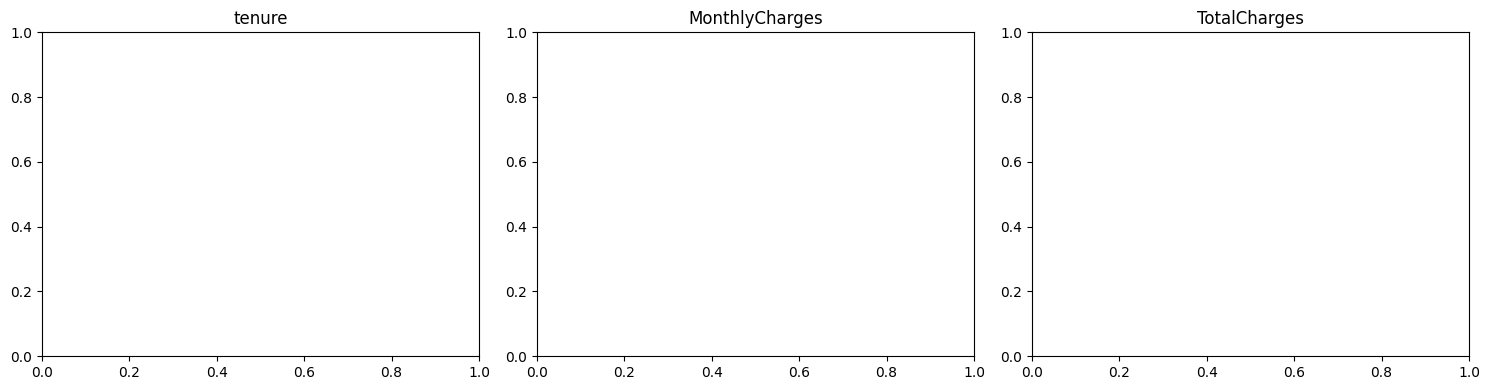

In [288]:
plt.figure(figsize=(15,4))

for i, col in enumerate(numerical_features):
    plt.subplot(1, len(numerical_features), i+1)
    plt.title(col)

plt.tight_layout()
plt.show()

No significant outliers were observed in numerical features. TotalCharges showed right skewness but no extreme outliers, so no removal was performed.

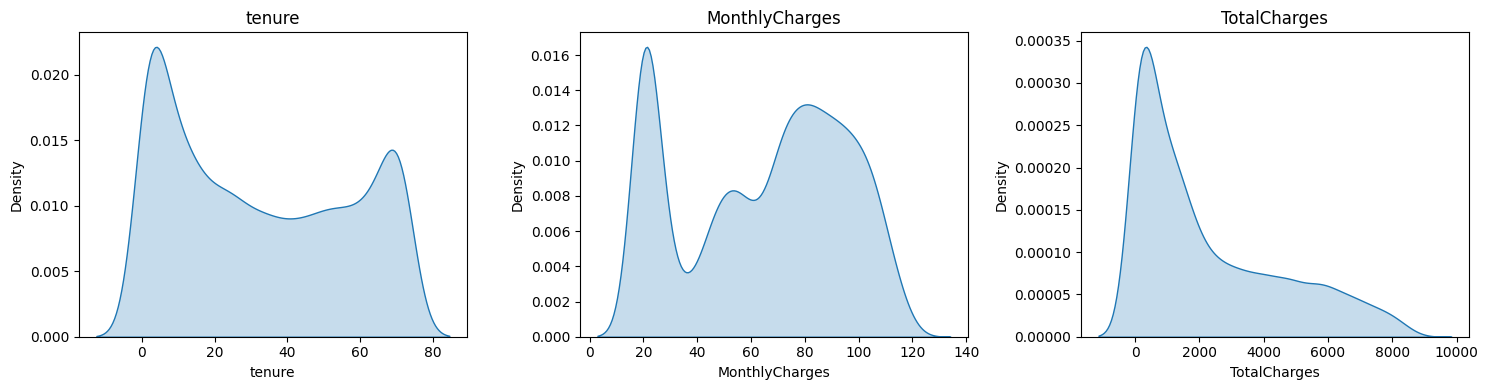

In [289]:
plt.figure(figsize=(15,4))

for i, col in enumerate(numerical_features):
    plt.subplot(1, len(numerical_features), i+1)
    sns.kdeplot(dataset[col], fill=True)
    plt.title(col)

plt.tight_layout()
plt.show()

Most customers have low tenure and low total charges, indicating many are new customers, while a smaller group of long-term customers contributes to higher total charges. MonthlyCharges shows two distinct groups, suggesting different pricing plans.


In [290]:
dataset[categorical_features].nunique()

gender              2
SeniorCitizen       2
Partner             2
Dependents          2
PhoneService        2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
PaperlessBilling    2
PaymentMethod       4
dtype: int64

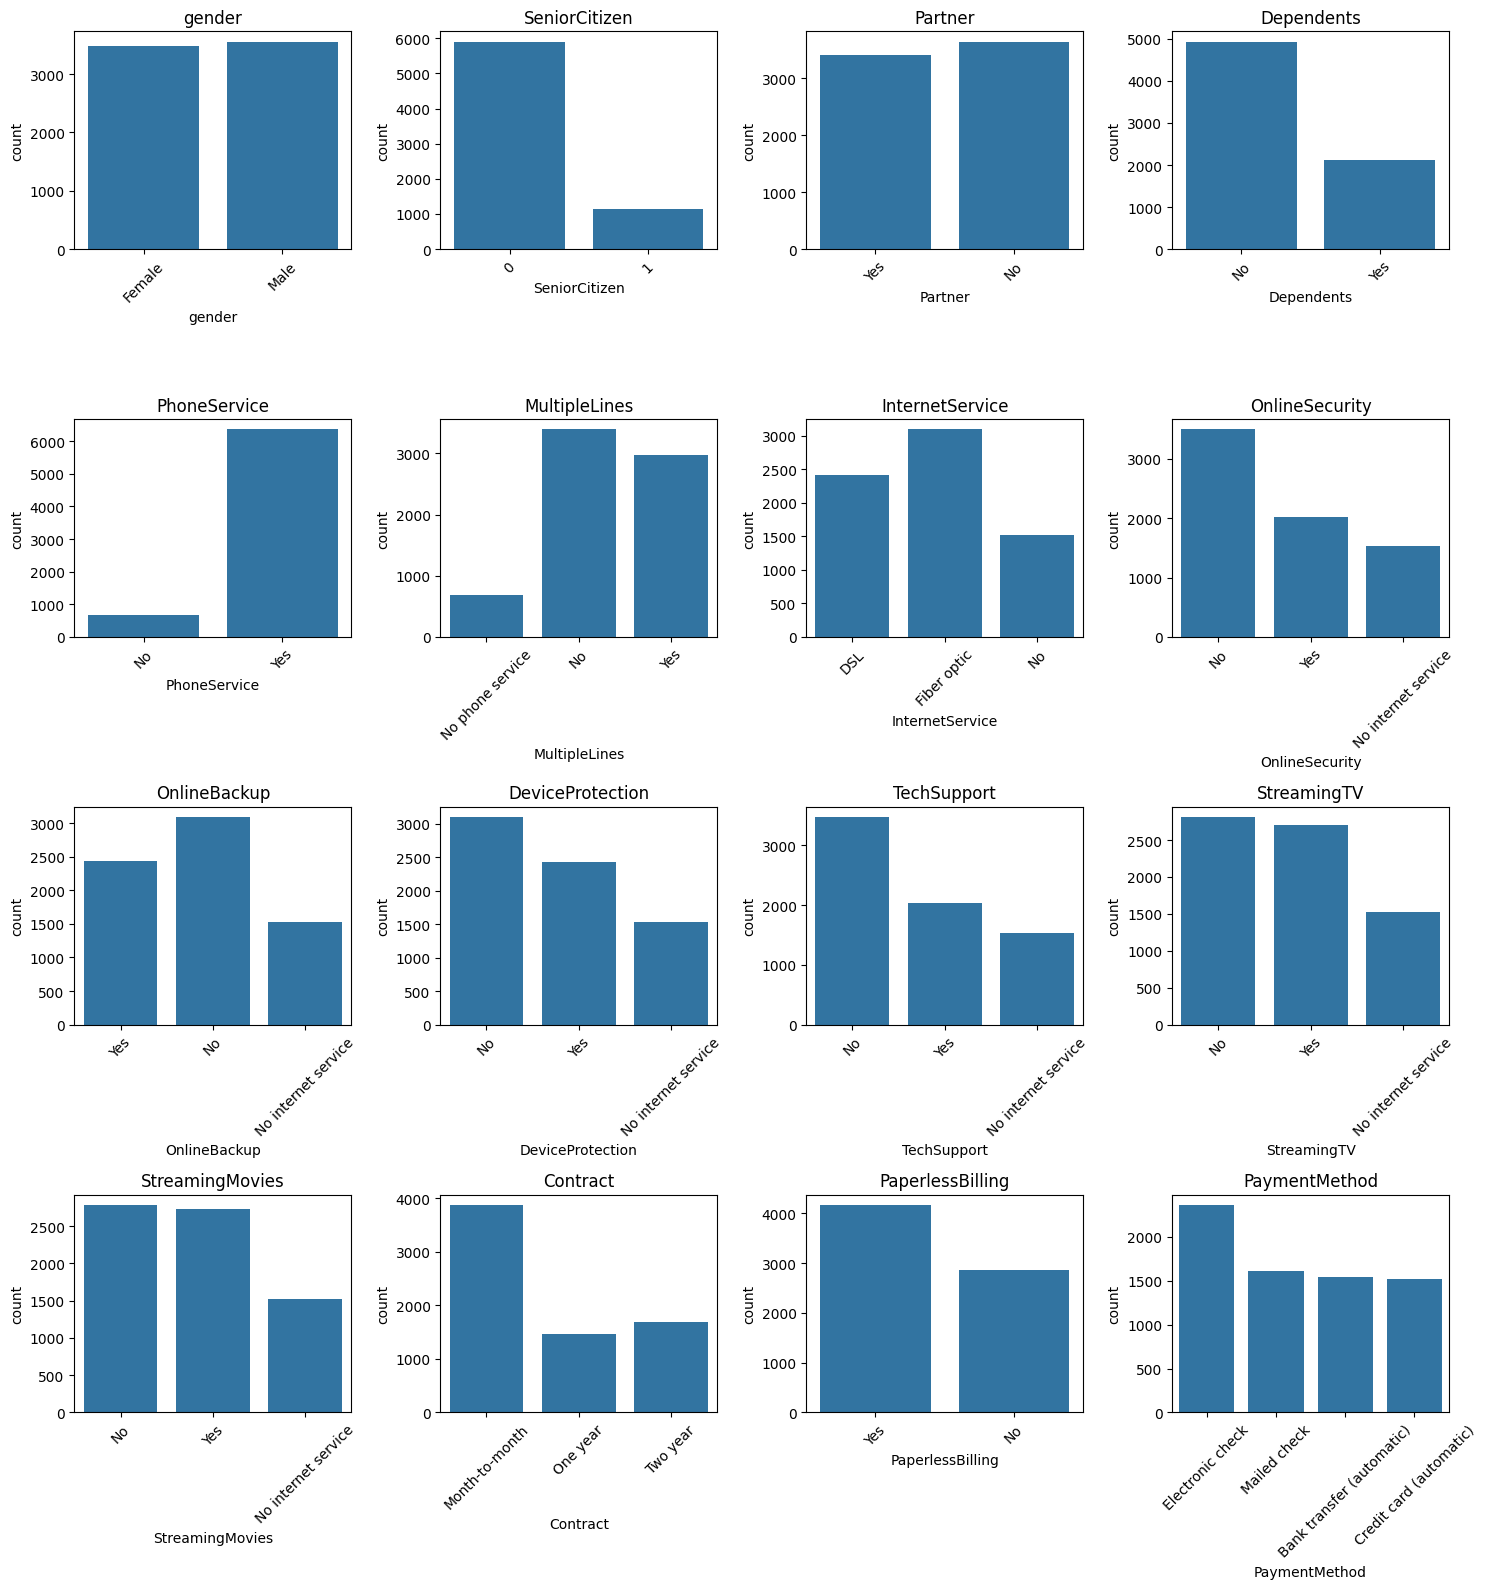

In [291]:
n = len(categorical_features)
cols = 4
rows = math.ceil(n / cols)

plt.figure(figsize=(15, 4 * rows))

for i, col in enumerate(categorical_features):
    plt.subplot(rows, cols, i+1)
    sns.countplot(x=col, data=dataset)
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Most customers are on month-to-month contracts, use fiber internet, and do not have additional services like tech support or security.

## Bivariate analysis

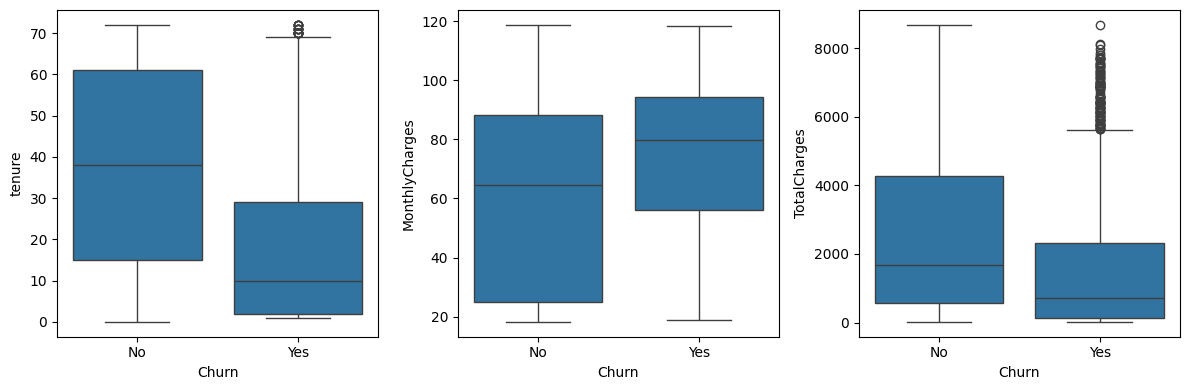

In [292]:
plt.figure(figsize=(12,4))

for i, col in enumerate(numerical_features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='Churn', y=col, data=dataset)

plt.tight_layout()
plt.show()

Customers with low tenure, high monthly charges, and low total charges are more likely to churn.

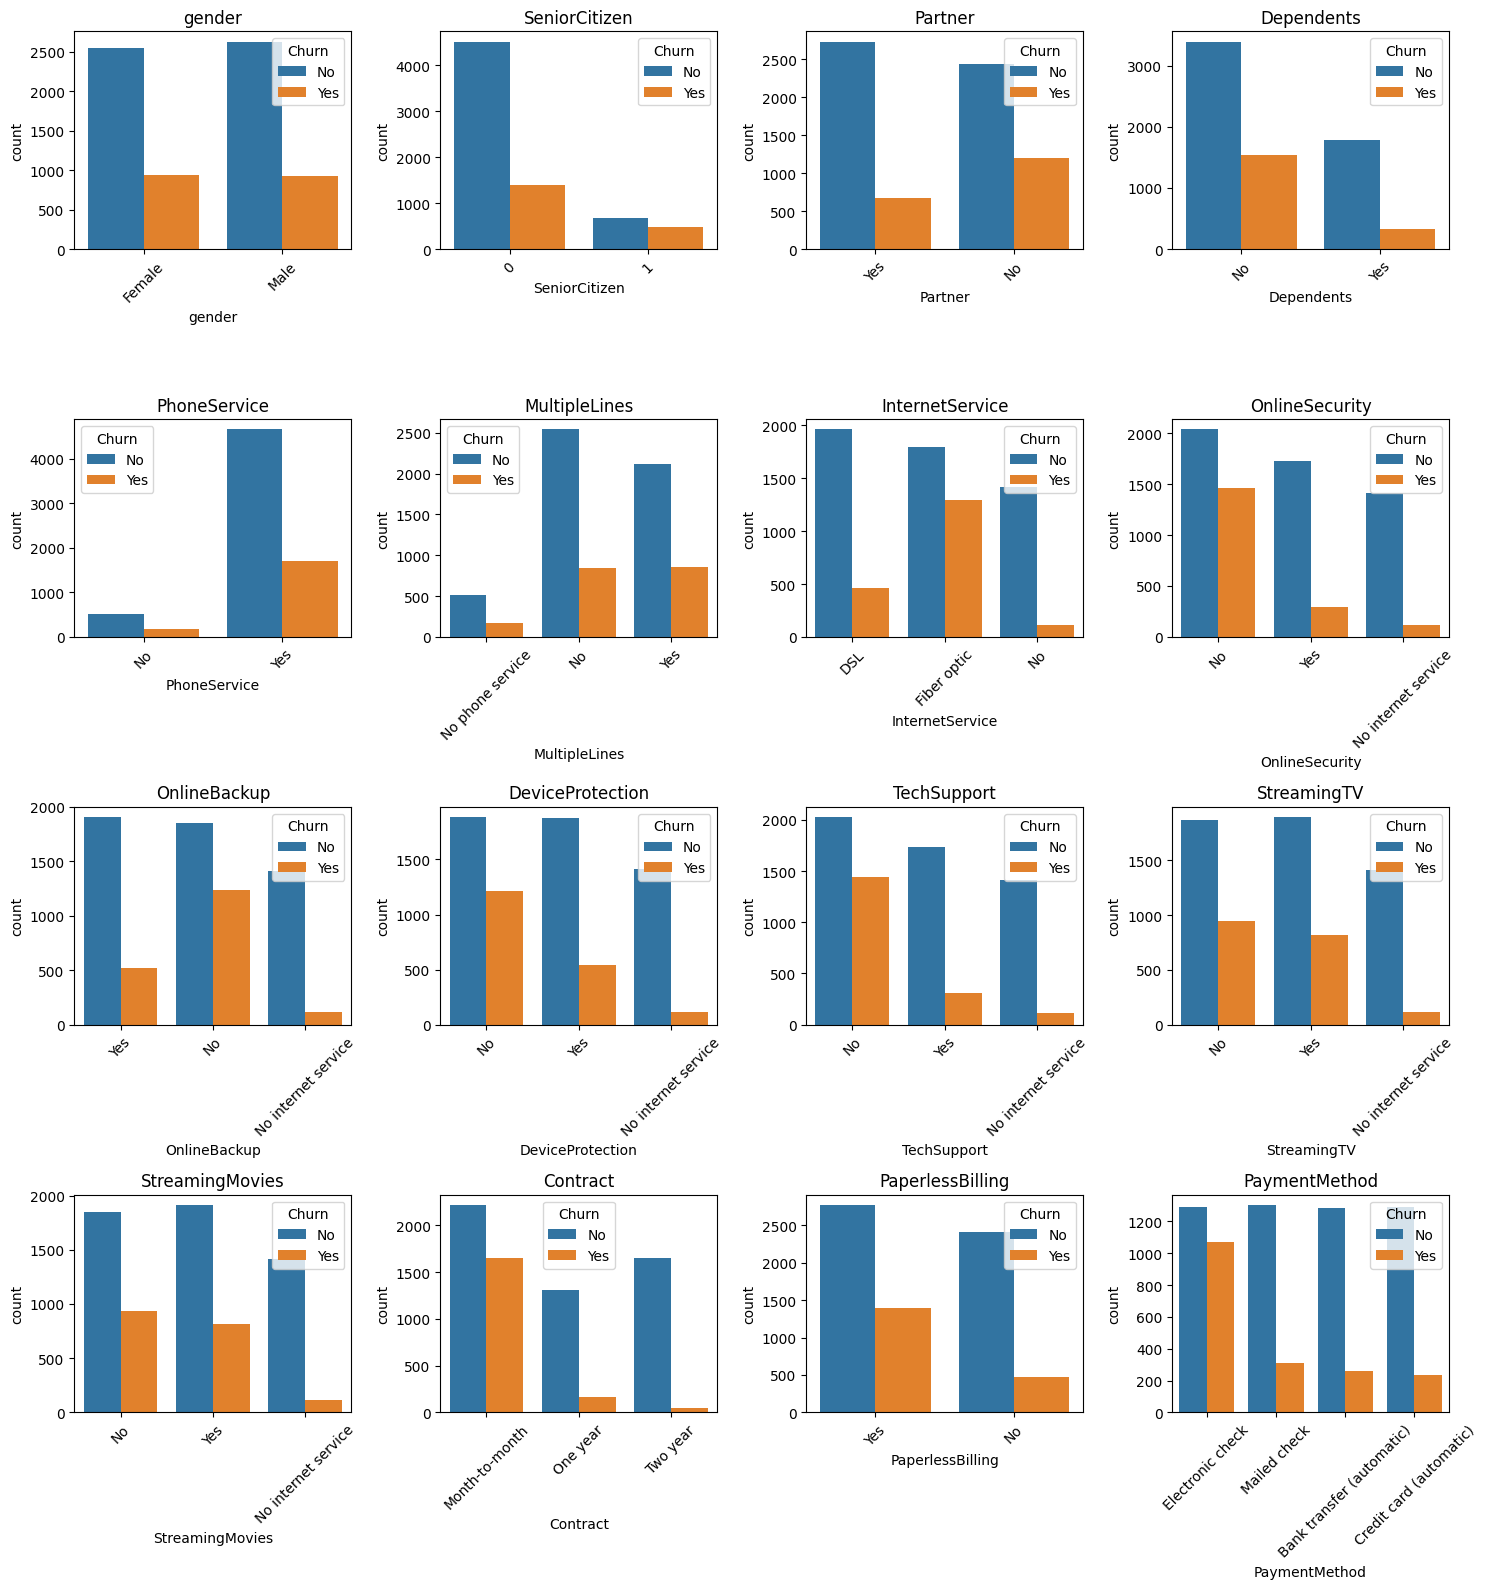

In [293]:
n = len(categorical_features)
cols = 4
rows = math.ceil(n / cols)

plt.figure(figsize=(15, 4 * rows))

for i, col in enumerate(categorical_features):
    plt.subplot(rows, cols, i+1)
    sns.countplot(x=col, hue='Churn', data=dataset)
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Customers who are on month-to-month contracts, use fiber internet, lack services like tech support and security, and pay via electronic check are more likely to churn.

In [294]:
dataset.drop(columns=['customerID'], inplace=True)

In [295]:
X = dataset.drop('Churn', axis=1)
y = dataset['Churn']

In [296]:
print(X.shape)
print(y.shape)

(7043, 19)
(7043,)


In [297]:
y.head

<bound method NDFrame.head of 0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7043, dtype: str>

In [298]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='str')

## Feature Encoding

In [299]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [300]:
X_train.shape

(5634, 19)

In [301]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3738,Male,0,No,No,35,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65
3151,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55
4860,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35
3867,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70
3810,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55


In [302]:
X_test.shape

(1409, 19)

For binary categories we will perform Label Encoding and for Multi-category we willl perform One-Hot Encoding.

In [303]:
binary_cols = [col for col in categorical_features if X[col].nunique() == 2]
multi_cols = [col for col in categorical_features if X[col].nunique() > 2]

print("Binary:", binary_cols)
print("Multi:", multi_cols)

Binary: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [304]:
X_train['gender'].value_counts()

X_train['gender'] = X_train['gender'].map({'Male':1, 'Female':0})
X_test['gender'] = X_test['gender'].map({'Male':1, 'Female':0})

In [305]:
X_train['gender'].value_counts()

gender
1    2833
0    2801
Name: count, dtype: int64

In [306]:
X_train['SeniorCitizen'].value_counts() #already in numeric

SeniorCitizen
0    4714
1     920
Name: count, dtype: int64

In [307]:
for cols in binary_cols:
    print(X_train[cols].value_counts())


gender
1    2833
0    2801
Name: count, dtype: int64
SeniorCitizen
0    4714
1     920
Name: count, dtype: int64
Partner
No     2905
Yes    2729
Name: count, dtype: int64
Dependents
No     3955
Yes    1679
Name: count, dtype: int64
PhoneService
Yes    5075
No      559
Name: count, dtype: int64
PaperlessBilling
Yes    3331
No     2303
Name: count, dtype: int64


In [308]:
#for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    #print(col, X_train[col].unique())

In [309]:
#for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
   # X_train[col] = X_train[col].astype(str).str.strip()
    #X_test[col] = X_test[col].astype(str).str.strip()

In [310]:
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    X_train[col] = X_train[col].map({'Yes':1, 'No':0})
    X_test[col] = X_test[col].map({'Yes':1, 'No':0})

In [311]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3738,1,0,0,0,35,0,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,0,Electronic check,49.20,1701.65
3151,1,0,1,1,15,1,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,0,Mailed check,75.10,1151.55
4860,1,0,1,1,13,0,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,0,Mailed check,40.55,590.35
3867,0,0,1,0,26,1,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,1,Credit card (automatic),73.50,1905.70
3810,1,0,1,1,1,1,No,DSL,No,No,No,No,No,No,Month-to-month,0,Electronic check,44.55,44.55


In [312]:
X_test.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
437,1,0,1,1,72,1,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,1,Credit card (automatic),114.05,8468.20
2280,0,1,0,0,8,1,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,1,Credit card (automatic),100.15,908.55
2235,0,0,1,1,41,1,Yes,DSL,Yes,Yes,Yes,No,Yes,No,One year,1,Credit card (automatic),78.35,3211.20
4460,1,0,1,0,18,1,No,Fiber optic,No,No,Yes,Yes,No,No,Month-to-month,0,Electronic check,78.20,1468.75
3761,0,0,1,0,72,1,Yes,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,1,Credit card (automatic),82.65,5919.35


In [313]:
X_train.isnull().sum().sum()

np.int64(0)

In [314]:
#Lets Handle multi-category cols
for cols in multi_cols:
    print(X_train[cols].value_counts())

MultipleLines
No                  2685
Yes                 2390
No phone service     559
Name: count, dtype: int64
InternetService
Fiber optic    2483
DSL            1937
No             1214
Name: count, dtype: int64
OnlineSecurity
No                     2797
Yes                    1623
No internet service    1214
Name: count, dtype: int64
OnlineBackup
No                     2442
Yes                    1978
No internet service    1214
Name: count, dtype: int64
DeviceProtection
No                     2472
Yes                    1948
No internet service    1214
Name: count, dtype: int64
TechSupport
No                     2771
Yes                    1649
No internet service    1214
Name: count, dtype: int64
StreamingTV
No                     2226
Yes                    2194
No internet service    1214
Name: count, dtype: int64
StreamingMovies
No                     2217
Yes                    2203
No internet service    1214
Name: count, dtype: int64
Contract
Month-to-month    3102
Two ye

Most of the features have 'No internet service' and 'No phone service' it directly means no. So, we will map it to no and later we can do label encoding on top

In [315]:
for col in multi_cols:
    X_train[col] = X_train[col].replace({
        'No internet service': 'No',
        'No phone service': 'No'
    })
    X_test[col] = X_test[col].replace({
        'No internet service': 'No',
        'No phone service': 'No'
    })

After mapping service-related categories to ‘No’, binary features were encoded using 0/1, while multi-category features were handled using one-hot encoding.”

In [316]:
binary_features = [col for col in multi_cols if X_train[col].nunique() == 2]

In [317]:
binary_features

['MultipleLines',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies']

In [318]:
for col in binary_features:
    X_train[col] = X_train[col].map({'Yes':1, 'No':0})
    X_test[col] = X_test[col].map({'Yes':1, 'No':0})

In [319]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3738,1,0,0,0,35,0,0,DSL,0,0,1,0,1,1,Month-to-month,0,Electronic check,49.20,1701.65
3151,1,0,1,1,15,1,0,Fiber optic,1,0,0,0,0,0,Month-to-month,0,Mailed check,75.10,1151.55
4860,1,0,1,1,13,0,0,DSL,1,1,0,1,0,0,Two year,0,Mailed check,40.55,590.35
3867,0,0,1,0,26,1,0,DSL,0,1,1,0,1,1,Two year,1,Credit card (automatic),73.50,1905.70
3810,1,0,1,1,1,1,0,DSL,0,0,0,0,0,0,Month-to-month,0,Electronic check,44.55,44.55


In [320]:
#Lets Handle multi-category cols
features_for_one_hot_encoding = [col for col in categorical_features if X_train[col].nunique() > 2]

In [321]:
features_for_one_hot_encoding


['InternetService', 'Contract', 'PaymentMethod']

In [322]:
for col in features_for_one_hot_encoding:
    print(X_train[col].value_counts())

InternetService
Fiber optic    2483
DSL            1937
No             1214
Name: count, dtype: int64
Contract
Month-to-month    3102
Two year          1359
One year          1173
Name: count, dtype: int64
PaymentMethod
Electronic check             1891
Mailed check                 1286
Bank transfer (automatic)    1244
Credit card (automatic)      1213
Name: count, dtype: int64


Here we can see that InternetService and PaymentMethod are nominal feature and Contract looks like oridinal. So we will do one hot encoding on nominal features and label encoding on oridnal ones. (Month-to-month': 0, 'One year': 1, 'Two year': 2)

In [323]:
#One Hot Encoding

X_train = pd.get_dummies(X_train, columns=['PaymentMethod', 'InternetService'], drop_first=True, dtype=int) #set dtype int to get 0/1 values else get dummies gives boolean values
X_test = pd.get_dummies(X_test, columns=['PaymentMethod', 'InternetService'], drop_first=True, dtype=int)

In [324]:
#Label Encoding
X_train['Contract'] = X_train['Contract'].map({
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
})
X_test['Contract'] = X_test['Contract'].map({
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
})

In [325]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 22 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 5634 non-null   int64  
 1   SeniorCitizen                          5634 non-null   int64  
 2   Partner                                5634 non-null   int64  
 3   Dependents                             5634 non-null   int64  
 4   tenure                                 5634 non-null   int64  
 5   PhoneService                           5634 non-null   int64  
 6   MultipleLines                          5634 non-null   int64  
 7   OnlineSecurity                         5634 non-null   int64  
 8   OnlineBackup                           5634 non-null   int64  
 9   DeviceProtection                       5634 non-null   int64  
 10  TechSupport                            5634 non-null   int64  
 11  StreamingTV      

In [326]:
X_test.info()

<class 'pandas.DataFrame'>
Index: 1409 entries, 437 to 5613
Data columns (total 22 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 1409 non-null   int64  
 1   SeniorCitizen                          1409 non-null   int64  
 2   Partner                                1409 non-null   int64  
 3   Dependents                             1409 non-null   int64  
 4   tenure                                 1409 non-null   int64  
 5   PhoneService                           1409 non-null   int64  
 6   MultipleLines                          1409 non-null   int64  
 7   OnlineSecurity                         1409 non-null   int64  
 8   OnlineBackup                           1409 non-null   int64  
 9   DeviceProtection                       1409 non-null   int64  
 10  TechSupport                            1409 non-null   int64  
 11  StreamingTV       

In [327]:
y_train = y_train.map({'Yes':1, 'No':0})
y_test = y_test.map({'Yes':1, 'No':0})

## Feature Engineering

I engineered features like total services used and contract type to capture customer engagement and commitment, which significantly influence churn behavior.

In [328]:
service_cols = [
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies'
]

X_train['TotalServices'] = X_train[service_cols].sum(axis=1)
X_test['TotalServices'] = X_test[service_cols].sum(axis=1)

In [329]:
X_train['IsMonthlyContract'] = (X_train['Contract'] == 0).astype(int)
X_test['IsMonthlyContract'] = (X_test['Contract'] == 0).astype(int)

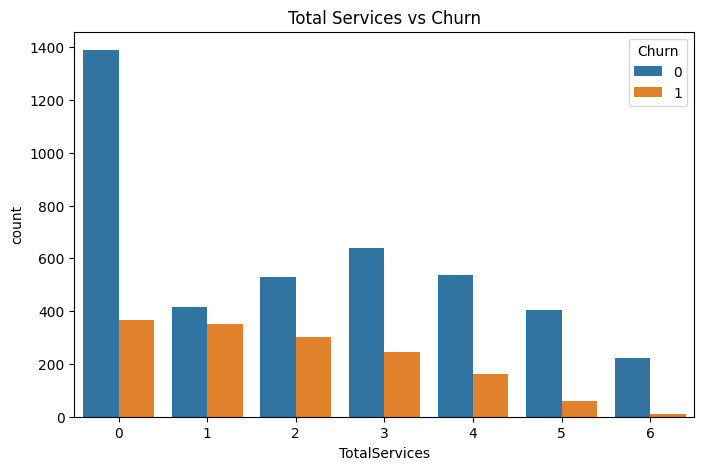

In [330]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x='TotalServices', hue=y_train, data=X_train)
plt.title("Total Services vs Churn")
plt.show()

Customers with fewer subscribed services show significantly higher churn, while customers using multiple services are more likely to stay. This indicates that higher product engagement reduces churn.

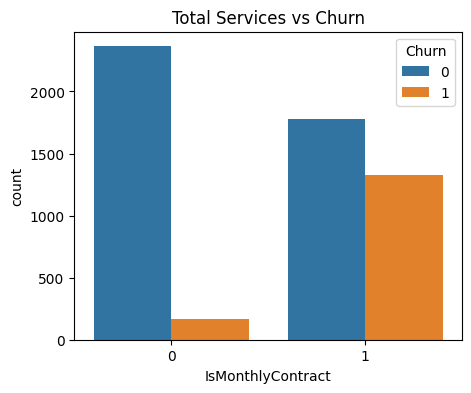

In [331]:
plt.figure(figsize=(5,4))
sns.countplot(x='IsMonthlyContract', hue=y_train, data=X_train)
plt.title("Total Services vs Churn")
plt.show()

Customers on month-to-month contracts exhibit significantly higher churn compared to those on long-term contracts, indicating that lack of commitment increases churn risk.

## Feature Scaling

Although most features are binary (0/1), numerical features like tenure, MonthlyCharges, and TotalCharges have larger ranges. Since models like Logistic Regression are sensitive to feature scale, we apply StandardScaler to ensure all features contribute equally.

In [332]:
scaler = StandardScaler()

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [333]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No,TotalServices,IsMonthlyContract
3738,1,0,0,0,0.102371,0,0,0,0,1,...,0,-0.521976,-0.263289,0,1,0,0,0,3,1
3151,1,0,1,1,-0.711743,1,0,1,0,0,...,0,0.337478,-0.504814,0,0,1,1,0,1,1
4860,1,0,1,1,-0.793155,0,0,1,1,0,...,0,-0.809013,-0.751213,0,0,1,0,0,3,0
3867,0,0,1,0,-0.263980,1,0,0,1,1,...,1,0.284384,-0.173699,1,0,0,0,0,4,0
3810,1,0,1,1,-1.281624,1,0,0,0,0,...,0,-0.676279,-0.990851,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6303,0,0,1,0,1.567778,1,1,0,1,1,...,0,1.470695,2.373711,0,1,0,1,0,5,0
6227,1,0,0,0,-1.240918,1,0,0,0,0,...,0,-0.626504,-0.975133,0,0,0,0,0,0,1
4673,0,1,0,0,-0.304686,1,1,1,1,0,...,1,1.256662,0.157569,0,0,1,1,0,4,1
2710,0,0,1,0,-0.345392,1,0,0,0,0,...,0,-1.477661,-0.798434,1,0,0,0,1,0,0


In [334]:
X_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No,TotalServices,IsMonthlyContract
437,1,0,1,1,1.608483,1,1,1,1,1,...,1,1.629976,2.707614,1,0,0,1,0,6,0
2280,0,1,0,0,-0.996684,1,1,0,0,0,...,1,1.168725,-0.611505,1,0,0,1,0,3,1
2235,0,0,1,1,0.346606,1,1,1,1,1,...,1,0.445324,0.399490,1,0,0,0,0,4,0
4460,1,0,1,0,-0.589626,1,0,0,0,1,...,0,0.440347,-0.365546,0,1,0,1,0,2,1
3761,0,0,1,0,1.608483,1,1,1,1,1,...,1,0.588013,1.588523,1,0,0,0,0,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5143,0,0,1,1,0.672252,1,0,1,1,1,...,1,0.738999,0.897293,0,0,1,0,0,6,0
4439,1,0,1,1,-0.182569,1,0,0,0,0,...,1,-1.480980,-0.796173,1,0,0,0,1,0,0
3857,1,0,0,0,-1.118801,1,0,0,0,0,...,0,-1.469365,-0.969337,0,0,0,0,1,0,1
4758,0,0,0,0,0.957192,1,0,0,0,0,...,0,-1.500890,-0.548567,0,0,0,0,1,0,0


In [335]:
X_train[0:1]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No,TotalServices,IsMonthlyContract
3738,1,0,0,0,0.102371,0,0,0,0,1,...,0,-0.521976,-0.263289,0,1,0,0,0,3,1


In [336]:
X_train.isnull().sum().sum()
X_test.isnull().sum().sum()


np.int64(0)

In [337]:
X_train.columns.equals(X_test.columns)

True

## Model Training, Evaluation, and Selection

In [338]:
def evaluate_model(name, y_test, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

### Logistic Regression

In [339]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

In [340]:
lr_results = evaluate_model('Logistic Regression', y_test, y_pred_lr, y_prob_lr)
lr_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.7374024130589071,
 'Precision': 0.5034364261168385,
 'Recall': 0.7834224598930482,
 'F1 Score': 0.6129707112970711,
 'ROC-AUC': 0.8416388953473353}

Logistic Regression achieved high recall, making it effective at identifying churn customers. Despite moderate precision, the trade-off is acceptable, and the strong ROC-AUC indicates good overall performance.

### Random Forest

In [341]:
rf = RandomForestClassifier(
    class_weight='balanced', random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [342]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [343]:
rf_results = evaluate_model('Random Forest', y_test, y_pred_rf, y_prob_rf)
rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.7792760823278921,
 'Precision': 0.6120996441281139,
 'Recall': 0.45989304812834225,
 'F1 Score': 0.5251908396946565,
 'ROC-AUC': 0.8255315301351107}

Random Forest improved precision but significantly reduced recall, making it less suitable for churn prediction where identifying more churn customers is important.

### XGBOOST

In [ ]:
xgb = XGBClassifier(scale_pos_weight = (len(y_train[y_train==0]) / len(y_train[y_train==1])))
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [345]:
xgb_results = evaluate_model("XGBOOST", y_test, y_pred_xgb, y_prob_xgb)
xgb_results

{'Model': 'XGBOOST',
 'Accuracy': 0.7665010645848119,
 'Precision': 0.547568710359408,
 'Recall': 0.6925133689839572,
 'F1 Score': 0.6115702479338843,
 'ROC-AUC': 0.8248030173861376}

XGBoost achieves a good balance between precision and recall, with improved recall compared to Random Forest, making it a suitable model for churn prediction.

In [370]:
results = [lr_results, rf_results, xgb_results]

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.737402,0.503436,0.783422,0.612971,0.841639
1,Random Forest,0.779276,0.612100,0.459893,0.525191,0.825532
2,XGBOOST,0.766501,0.547569,0.692513,0.611570,0.824803


Logistic Regression performs best overall with the highest recall and ROC-AUC, making it the most suitable model for churn prediction, while XGBoost provides a balanced alternative and Random Forest underperforms due to low recall.

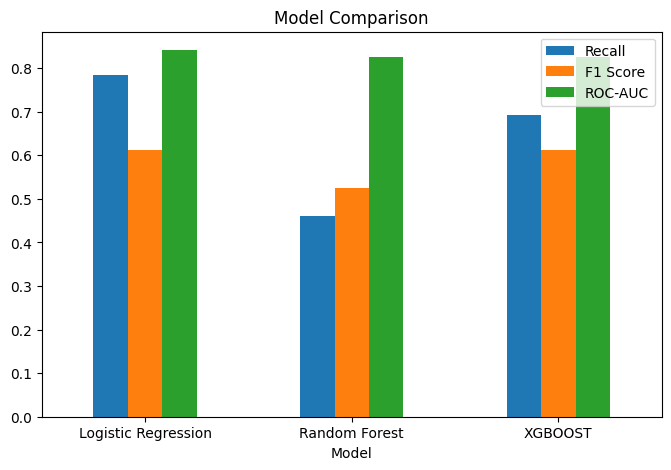

In [347]:
results_df.set_index('Model')[['Recall','F1 Score','ROC-AUC']].plot(kind='bar', figsize=(8,5))
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.show()

## Cross Validation on Models

In [348]:
from sklearn.model_selection import cross_val_score

In [349]:
for model, name in [(lr, "LR"), (rf, "RF"), (xgb, "XGB")]:
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='recall')
    print(name, scores.mean())

LR 0.8046822742474916
RF 0.47090301003344476
XGB 0.6494983277591974


Cross-validation confirms that Logistic Regression consistently achieves the highest recall, reinforcing it as the most reliable model for identifying churn customers.

## Hyperparameter tuning

In [359]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000),
    param_grid,
    scoring='recall',   # IMPORTANT
    cv=5
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print(grid.best_params_)

{'C': 1, 'solver': 'lbfgs'}


Hyperparameter tuning did not significantly improve the Logistic Regression model, as the best parameters were similar to the default configuration. This indicates that the model was already well-optimized.

In [363]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier


# Parameter grid (balanced, not too large)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# GridSearch
grid_xgb = GridSearchCV(
    XGBClassifier( scale_pos_weight = (len(y_train[y_train==0]) / len(y_train[y_train==1])),
    eval_metric='logloss',
    random_state=42),
    param_grid=param_grid,
    scoring='recall',   # IMPORTANT for churn
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit
grid_xgb.fit(X_train, y_train)

# Best model
best_xgb = grid_xgb.best_estimator_

# Best params
print("Best Params:", grid_xgb.best_params_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


In [364]:
from xgboost import XGBClassifier

xgb_tuned = XGBClassifier(
    colsample_bytree=1.0,
    learning_rate=0.05,
    max_depth=3,
    n_estimators=100,
    subsample=1.0,
    scale_pos_weight = (len(y_train[y_train==0]) / len(y_train[y_train==1])),
    eval_metric='logloss',
    random_state=42
)

In [367]:
xgb_tuned.fit(X_train, y_train)

y_pred_xgb = xgb_tuned.predict(X_test)
y_prob_xgb = xgb_tuned.predict_proba(X_test)[:, 1]

In [ ]:
xgb_tuned_results = evaluate_model("XGBOOST_tuned", y_test, y_pred_xgb, y_prob_xgb)
xgb_tuned_results

{'Model': 'XGBOOST_tuned',
 'Accuracy': 0.7494677075940384,
 'Precision': 0.5180722891566265,
 'Recall': 0.8048128342245989,
 'F1 Score': 0.6303664921465969,
 'ROC-AUC': 0.8454002945051537}

In [372]:
results_tuned = [lr_results, xgb_tuned_results]

results_tuned = pd.DataFrame(results_tuned)
results_tuned

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.737402,0.503436,0.783422,0.612971,0.841639
1,XGBOOST_tuned,0.749468,0.518072,0.804813,0.630366,0.845400


After hyperparameter tuning, XGBoost outperformed Logistic Regression by achieving higher recall, F1-score, and ROC-AUC. Therefore, XGBoost was selected as the final model for churn prediction.

In [ ]:
y_prob = y_prob_xgb_tuned

for t in [0.3, 0.4, 0.5, 0.6]:
    y_pred = (y_prob > t).astype(int)
    print(t, recall_score(y_test, y_pred), precision_score(y_test, y_pred))